In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Visual settings for plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

## Data Loading

In [ ]:
caminho_arquivo = 'data/raw/hepg2.csv'
df = pd.read_csv(caminho_arquivo)

# Display the first rows to confirm reading
display(df.head())

# Selecting predictor variables (Features - X) and target variable (y)
X = df[['% DMSO', 'TREHALOSE']]
y = df['VIABILIDADE']

,INDEX,ESPÉCIE/LINHAGEM,% DMSO,TREHALOSE,% SFB,VIABILIDADE
0,1,HepG2,2.0,0.0,98.0,97.33
1,2,HepG2,2.0,0.0,98.0,93.33
2,3,HepG2,2.0,0.0,98.0,92.75
3,4,HepG2,2.0,0.0,98.0,94.66
4,5,HepG2,2.0,0.0,98.0,95.83


## Dataset Split and Model Training (Avoiding Overfitting)

In [ ]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

## Validation

In [ ]:
y_pred = rf_model.predict(X_test)

# R2 and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# K-Fold ; K = 5
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='r2')
mean_cv_r2 = cv_scores.mean()

print(f"Test performance -> R²: {r2:.4f} | RMSE: {rmse:.4f}")
print(f"Stability (Mean Cross-Validation R²): {mean_cv_r2:.4f}")

Desempenho no Teste -> R²: 0.9799 | RMSE: 4.9958
Estabilidade (Cross-Validation R² Médio): 0.9738


## Simulating all possible concentrations

In [ ]:
dmso_range = np.linspace(0, 100, 101)
treh_range = np.linspace(0, 100, 101)

# Generating all possible combinations of DMSO and trehalose
combinacoes = list(itertools.product(dmso_range, treh_range))
df_simulacao = pd.DataFrame(combinacoes, columns=['% DMSO', 'TREHALOSE'])

# Making predictions for the combinations
df_simulacao['VIABILIDADE_PREDITA'] = rf_model.predict(df_simulacao)

# Extracting the best scenarios
melhor_global = df_simulacao.sort_values(by='VIABILIDADE_PREDITA', ascending=False).head(5)
melhor_dmso_isolado = df_simulacao[df_simulacao['TREHALOSE'] == 0].sort_values(by='VIABILIDADE_PREDITA', ascending=False).head(5)
melhor_treh_isolada = df_simulacao[df_simulacao['% DMSO'] == 0].sort_values(by='VIABILIDADE_PREDITA', ascending=False).head(5)
melhor_combinado = df_simulacao[(df_simulacao['% DMSO'] > 0) & (df_simulacao['TREHALOSE'] > 0)].sort_values(by='VIABILIDADE_PREDITA', ascending=False).head(5)

print("--- TOP 5: BEST GLOBAL CONCENTRATIONS ---")
display(melhor_global)

print("\n--- TOP 5: BEST DMSO ALONE (No Trehalose) ---")
display(melhor_dmso_isolado)

print("\n--- TOP 5: BEST TREHALOSE ALONE (No DMSO) ---")
display(melhor_treh_isolada)

print("\n--- TOP 5: BEST COMBINED USE (Both present) ---")
display(melhor_combinado)

--- TOP 5: MELHORES CONCENTRAÇÕES GLOBAIS ---


,% DMSO,TREHALOSE,VIABILIDADE_PREDITA
303,3.0,0.0,95.17658
305,3.0,2.0,95.17658
304,3.0,1.0,95.17658
203,2.0,1.0,95.17658
204,2.0,2.0,95.17658



--- TOP 5: MELHOR DMSO ISOLADO (Sem Trehalose) ---


,% DMSO,TREHALOSE,VIABILIDADE_PREDITA
202,2.0,0.0,95.176580
303,3.0,0.0,95.176580
1010,10.0,0.0,92.043212
1111,11.0,0.0,92.043212
808,8.0,0.0,92.043212



--- TOP 5: MELHOR TREHALOSE ISOLADA (Sem DMSO) ---


,% DMSO,TREHALOSE,VIABILIDADE_PREDITA
16,0.0,16.0,78.401268
20,0.0,20.0,78.401268
19,0.0,19.0,78.401268
18,0.0,18.0,78.401268
17,0.0,17.0,78.401268



--- TOP 5: MELHOR USO COMBINADO (Ambos presentes) ---


,% DMSO,TREHALOSE,VIABILIDADE_PREDITA
305,3.0,2.0,95.176580
203,2.0,1.0,95.176580
204,2.0,2.0,95.176580
304,3.0,1.0,95.176580
911,9.0,2.0,92.043212


## Data Visualization

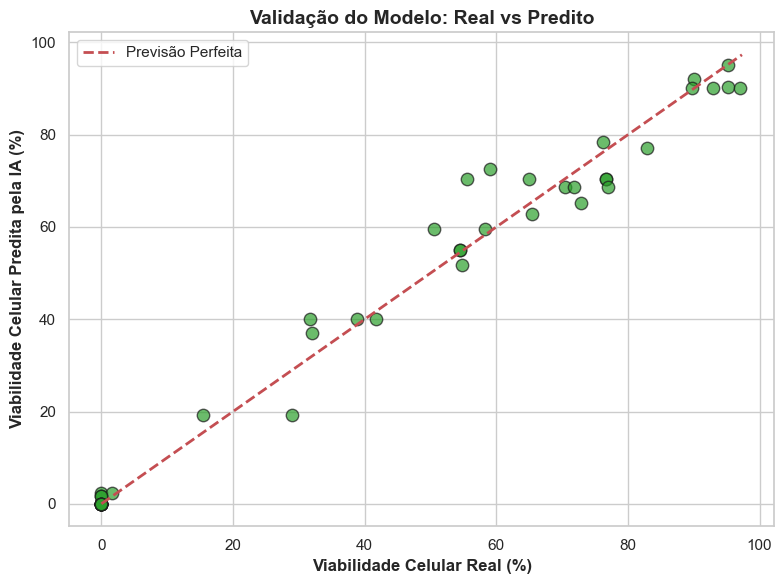

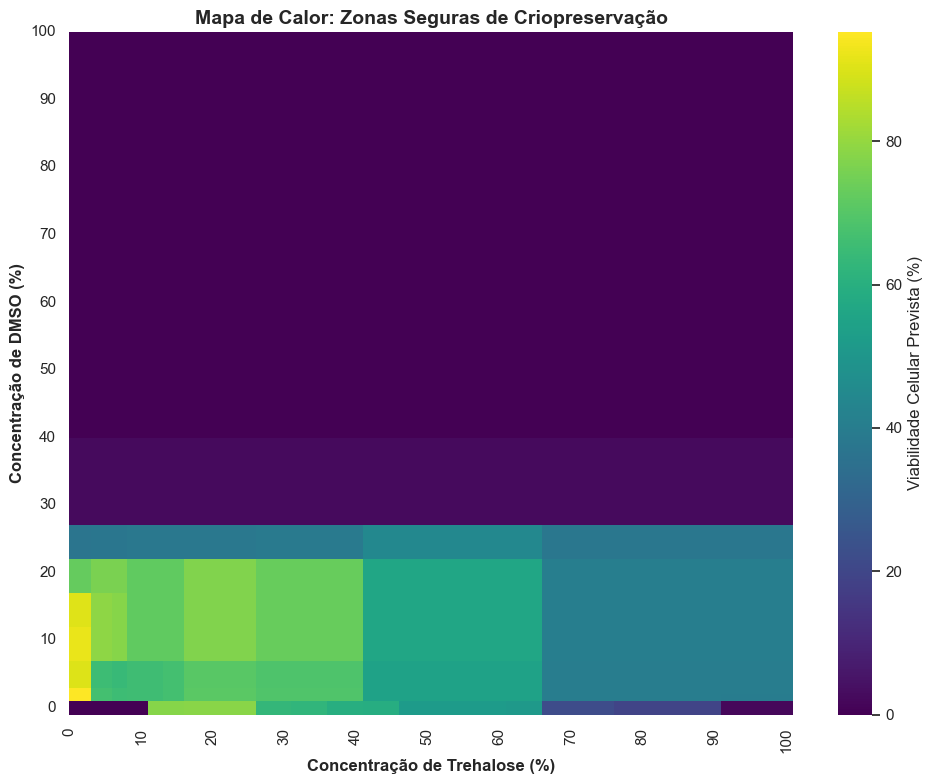

In [ ]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='#2ca02c', edgecolor='k', s=80)
# Line of perfection (where y_actual == y_predicted)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Cell Viability (%)', fontweight='bold')
plt.ylabel('AI Predicted Cell Viability (%)', fontweight='bold')
plt.title('Model Validation: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Viability Heatmap
matriz_calor = df_simulacao.pivot(index='% DMSO', columns='TREHALOSE', values='VIABILIDADE_PREDITA')

plt.figure(figsize=(10, 8))
ax = sns.heatmap(matriz_calor.iloc[::-1], cmap='viridis', 
                 cbar_kws={'label': 'Viabilidade Celular Prevista (%)'})

ax.set_xticks(np.arange(0, 101, 10))
ax.set_xticklabels(np.arange(0, 101, 10))
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels(np.arange(100, -1, -10))

plt.title('Heatmap: Safe Cryopreservation Zones', fontsize=14, fontweight='bold')
plt.xlabel('Trehalose Concentration (%)', fontweight='bold')
plt.ylabel('DMSO Concentration (%)', fontweight='bold')
plt.tight_layout()
plt.show()

## Exporting the .pkl model for web use

In [ ]:
caminho_modelo = 'random_forest_model.pkl'
joblib.dump(rf_model, caminho_modelo)
print(f"Model successfully exported to: {caminho_modelo}\n")

def predict_for_physician(dmso_input, trehalose_input):
    if dmso_input < 0 or trehalose_input < 0:
        return "Error: Concentrations cannot be negative."
    if dmso_input + trehalose_input > 100:
        return "Error: Sum of DMSO and trehalose concentrations exceeds total volume (100%)."
    
    entrada = pd.DataFrame({'% DMSO': [dmso_input], 'TREHALOSE': [trehalose_input]})
    modelo_carregado = joblib.load(caminho_modelo)
    viabilidade = modelo_carregado.predict(entrada)[0]
    
    return f"Analysis result: The combination of {dmso_input}% DMSO and {trehalose_input}% trehalose will result in cell viability of approximately {viabilidade:.2f}%." 

teste_1 = predict_for_physician(2.5, 1.0)
teste_2 = predict_for_physician(50.0, 10.0)

print(teste_1)
print(teste_2)

Modelo exportado com sucesso para: random_forest_model.pkl

Resultado da Análise: A combinação de 2.5% DMSO e 1.0% Trehalose resultará em uma viabilidade celular de aproximadamente 95.18%.
Resultado da Análise: A combinação de 50.0% DMSO e 10.0% Trehalose resultará em uma viabilidade celular de aproximadamente 0.00%.
